In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


# Loading Data

In [2]:
from pathlib import Path

test_path = Path('./UCI HAR Dataset/test')
train_path = Path('./UCI HAR Dataset/train')


## Feature Names

In [3]:
feature_names = pd.read_csv('./UCI HAR Dataset/features.txt', 
    sep=' ',
    index_col=0, 
    header=None)

# to fix the issue with duplicate column names we are going to append the letter to them with the indices
X_indices = slice(381,395)
X_indices_2 = slice(461,474)
X_indices_3 = slice(303,316)

Y_indices = slice(395,409)
Y_indices_2 = slice(474,488)
Y_indices_3 = slice(316,329)

Z_indices = slice(409,423)
Z_indices_2 = slice(488,502)
Z_indices_3 = slice(329,342)

feature_names[1][X_indices] = feature_names[1][X_indices] + '-X'
feature_names[1][X_indices_2] = feature_names[1][X_indices_2] + '-X'
feature_names[1][X_indices_3] = feature_names[1][X_indices_3] + '-X'

feature_names[1][Y_indices] = feature_names[1][Y_indices] + '-Y'
feature_names[1][Y_indices_2] = feature_names[1][Y_indices_2] + '-Y'
feature_names[1][Y_indices_3] = feature_names[1][Y_indices_3] + '-Y'

feature_names[1][Z_indices] = feature_names[1][Z_indices] + '-Z'
feature_names[1][Z_indices_2] = feature_names[1][Z_indices_2] + '-Z'
feature_names[1][Z_indices_3] = feature_names[1][Z_indices_3] + '-Z'

feature_names_list = feature_names[1].tolist()

print(f"There are {len(feature_names_list)} features, there are: {feature_names[1].nunique()} unique features")

There are 561 features, there are: 561 unique features


In [4]:
import pandas as pd
import polars as pl

def read_har_data(path):
    df = pd.read_csv(path, sep=r"\s+", header=None)
    df.columns = feature_names_list
    return df

X_train = read_har_data(train_path / 'X_train.txt')
X_test = read_har_data(test_path / 'X_test.txt')

In [5]:
activity_labels = pd.read_csv('./UCI HAR Dataset/activity_labels.txt', sep=' ', header=None, index_col=0)
activity_labels_map = activity_labels.to_dict()[1]

y_train = pd.read_csv(train_path / 'y_train.txt', sep=' ', header=None)
y_test = pd.read_csv(test_path / 'y_test.txt', sep=' ', header=None)
y_train = y_train[0].map(activity_labels_map)
y_test = y_test[0].map(activity_labels_map)



                    precision    recall  f1-score   support

            LAYING       1.00      0.96      0.98       537
           SITTING       0.87      0.78      0.82       491
          STANDING       0.82      0.93      0.87       532
           WALKING       0.82      0.95      0.88       496
WALKING_DOWNSTAIRS       0.90      0.73      0.81       420
  WALKING_UPSTAIRS       0.90      0.90      0.90       471

          accuracy                           0.88      2947
         macro avg       0.89      0.88      0.88      2947
      weighted avg       0.89      0.88      0.88      2947



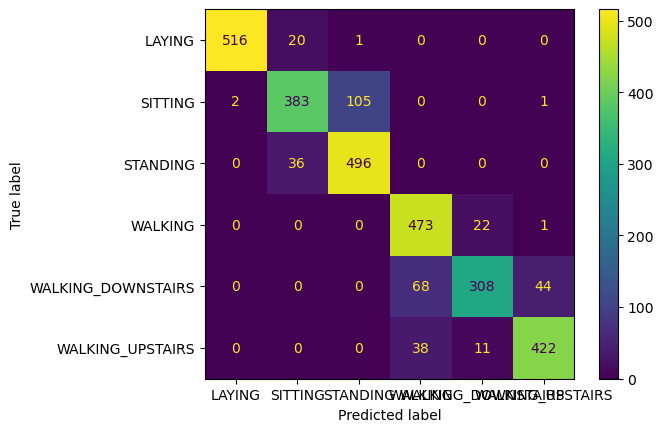

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

pipe = Pipeline([
    ('scaler', StandardScaler()),   # optional given pre-normalised data
    ('pca', PCA(n_components=0.95)),  # retain 95% of variance
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
cm

print(classification_report(y_test, y_pred))


In [9]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier()
rf = RandomForestClassifier()

mlp.fit(X_train, y_train)
rf.fit(X_train, y_train)

mlp_pred = mlp.predict(X_test)
rf_pred = rf.predict(X_test)

print('MLP:')
print(classification_report(y_test, mlp_pred))
print('')
print('RF')
print(classification_report(y_test, rf_pred))

MLP:
                    precision    recall  f1-score   support

            LAYING       1.00      0.98      0.99       537
           SITTING       0.95      0.90      0.93       491
          STANDING       0.90      0.96      0.93       532
           WALKING       0.94      0.98      0.96       496
WALKING_DOWNSTAIRS       0.98      0.94      0.96       420
  WALKING_UPSTAIRS       0.93      0.93      0.93       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947


RF
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.90      0.97      0.93       496
WALKING_DOWNSTAIRS       0.96      0.86      0.91       420
  WALKING_UPSTAIRS       0.